In [140]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [141]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [142]:
df = pd.read_csv("D:/resume-analyzer/ML/datasets/resume_dataset_200k_enhanced.csv")

In [143]:
# from src.skills import SKILLS
# import numpy as np
# import pandas as pd

# num_skills = len(SKILLS)

# skills_matrix = np.random.randint(0, 2, size=(len(df), num_skills))

# skills_df = pd.DataFrame(
#     skills_matrix,
#     columns=[f"skill_{s.replace(' ', '_')}" for s in SKILLS]
# )

# df = pd.concat([df, skills_df], axis=1)

In [144]:
df.head()

,candidate_id,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,company_type
0,1,27,Bachelors,Tier 2,8.16,2,7,2,2,0.33,0,0,21.0,1,5.62,409,MNC
1,2,24,Bachelors,Tier 3,6.35,3,2,2,2,4.99,0,0,11.0,1,9.66,237,Startup
2,3,33,Bachelors,Tier 3,7.78,0,2,4,2,0.93,0,0,15.0,1,8.12,435,Startup
3,4,31,Masters,Tier 3,6.92,2,1,4,1,0.37,0,0,11.5,1,7.19,340,MNC
4,5,28,Masters,Tier 2,8.24,3,0,1,2,0.33,0,0,5.0,0,4.09,371,Mid-size


In [145]:
print(df.columns)

Index(['candidate_id', 'age', 'education_level', 'university_tier', 'cgpa',
       'internships', 'projects', 'programming_languages', 'certifications',
       'experience_years', 'hackathons', 'research_papers', 'skills_score',
       'hired', 'soft_skills_score', 'resume_length_words', 'company_type'],
      dtype='str')


In [146]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   candidate_id           200000 non-null  int64  
 1   age                    200000 non-null  int64  
 2   education_level        200000 non-null  str    
 3   university_tier        200000 non-null  str    
 4   cgpa                   200000 non-null  float64
 5   internships            200000 non-null  int64  
 6   projects               200000 non-null  int64  
 7   programming_languages  200000 non-null  int64  
 8   certifications         200000 non-null  int64  
 9   experience_years       200000 non-null  float64
 10  hackathons             200000 non-null  int64  
 11  research_papers        200000 non-null  int64  
 12  skills_score           200000 non-null  float64
 13  hired                  200000 non-null  int64  
 14  soft_skills_score      200000 non-null  float64

In [147]:
df.describe()

,candidate_id,age,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,27.511705,7.499323,1.503015,2.996240,3.004420,1.000985,1.499030,0.498005,0.201950,14.000803,0.706060,6.502866,449.206975
std,57735.171256,4.030684,0.800952,1.225373,1.731104,1.412229,1.002217,1.497477,0.706773,0.448806,4.766263,0.455566,2.019637,120.103065
min,1.000000,21.000000,4.150000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000,-79.000000
25%,50000.750000,24.000000,6.960000,1.000000,2.000000,2.000000,0.000000,0.430000,0.000000,0.000000,10.500000,0.000000,4.750000,368.000000
50%,100000.500000,28.000000,7.500000,1.000000,3.000000,3.000000,1.000000,1.040000,0.000000,0.000000,14.000000,1.000000,6.510000,449.000000
75%,150000.250000,31.000000,8.040000,2.000000,4.000000,4.000000,2.000000,2.080000,1.000000,0.000000,17.000000,1.000000,8.250000,530.000000
max,200000.000000,34.000000,11.230000,10.000000,14.000000,5.000000,8.000000,23.550000,6.000000,5.000000,38.500000,1.000000,10.000000,956.000000


In [148]:
df['hired'].value_counts()

hired
1    141212
0     58788
Name: count, dtype: int64

In [149]:
df = df[df['resume_length_words']>0]

In [150]:
df = df[df['cgpa']<=10]

In [151]:
df.describe()

,candidate_id,age,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words
count,199799.000000,199799.000000,199799.00000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000
mean,99993.308170,27.511644,7.49685,1.503056,2.996046,3.004359,1.000976,1.499071,0.498026,0.201908,14.000300,0.706065,6.502618,449.242604
std,57736.357519,4.030542,0.79704,1.225417,1.730939,1.412225,1.002282,1.497524,0.706788,0.448746,4.766201,0.455564,2.019644,120.010013
min,1.000000,21.000000,4.15000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000,2.000000
25%,49995.500000,24.000000,6.96000,1.000000,2.000000,2.000000,0.000000,0.430000,0.000000,0.000000,10.500000,0.000000,4.750000,368.000000
50%,99989.000000,28.000000,7.50000,1.000000,3.000000,3.000000,1.000000,1.040000,0.000000,0.000000,14.000000,1.000000,6.510000,449.000000
75%,149993.500000,31.000000,8.04000,2.000000,4.000000,4.000000,2.000000,2.080000,1.000000,0.000000,17.000000,1.000000,8.250000,530.000000
max,200000.000000,34.000000,10.00000,10.000000,14.000000,5.000000,8.000000,23.550000,6.000000,5.000000,38.500000,1.000000,10.000000,956.000000


In [152]:
df = df.drop(columns=['candidate_id'])

In [153]:
df.head()

,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,company_type
0,27,Bachelors,Tier 2,8.16,2,7,2,2,0.33,0,0,21.0,1,5.62,409,MNC
1,24,Bachelors,Tier 3,6.35,3,2,2,2,4.99,0,0,11.0,1,9.66,237,Startup
2,33,Bachelors,Tier 3,7.78,0,2,4,2,0.93,0,0,15.0,1,8.12,435,Startup
3,31,Masters,Tier 3,6.92,2,1,4,1,0.37,0,0,11.5,1,7.19,340,MNC
4,28,Masters,Tier 2,8.24,3,0,1,2,0.33,0,0,5.0,0,4.09,371,Mid-size


In [154]:
df_without_more_experience = df[df['experience_years'] < 15]

In [155]:
df.describe()

,age,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words
count,199799.000000,199799.00000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000,199799.000000
mean,27.511644,7.49685,1.503056,2.996046,3.004359,1.000976,1.499071,0.498026,0.201908,14.000300,0.706065,6.502618,449.242604
std,4.030542,0.79704,1.225417,1.730939,1.412225,1.002282,1.497524,0.706788,0.448746,4.766201,0.455564,2.019644,120.010013
min,21.000000,4.15000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000,2.000000
25%,24.000000,6.96000,1.000000,2.000000,2.000000,0.000000,0.430000,0.000000,0.000000,10.500000,0.000000,4.750000,368.000000
50%,28.000000,7.50000,1.000000,3.000000,3.000000,1.000000,1.040000,0.000000,0.000000,14.000000,1.000000,6.510000,449.000000
75%,31.000000,8.04000,2.000000,4.000000,4.000000,2.000000,2.080000,1.000000,0.000000,17.000000,1.000000,8.250000,530.000000
max,34.000000,10.00000,10.000000,14.000000,5.000000,8.000000,23.550000,6.000000,5.000000,38.500000,1.000000,10.000000,956.000000


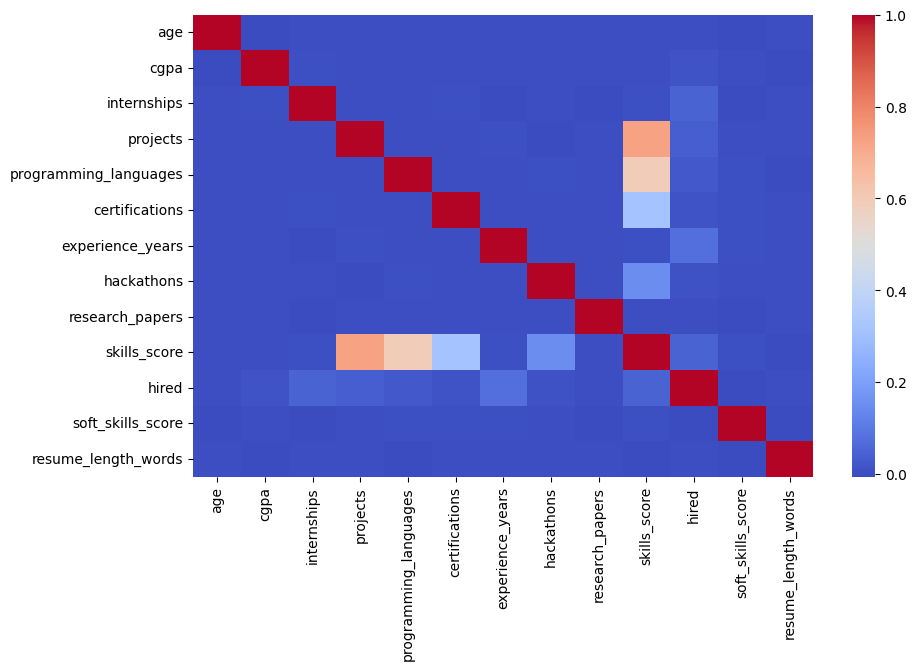

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

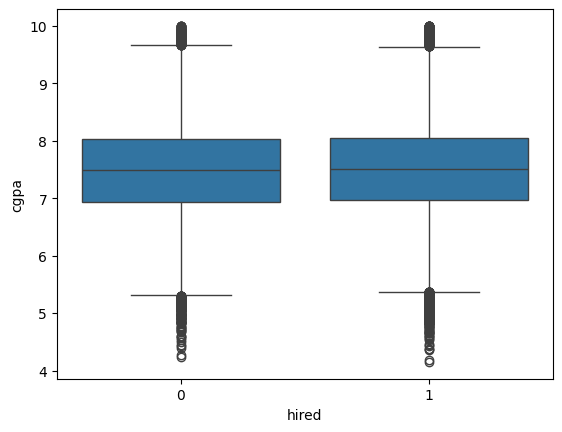

In [157]:
sns.boxplot(x='hired', y='cgpa', data=df)
plt.show()

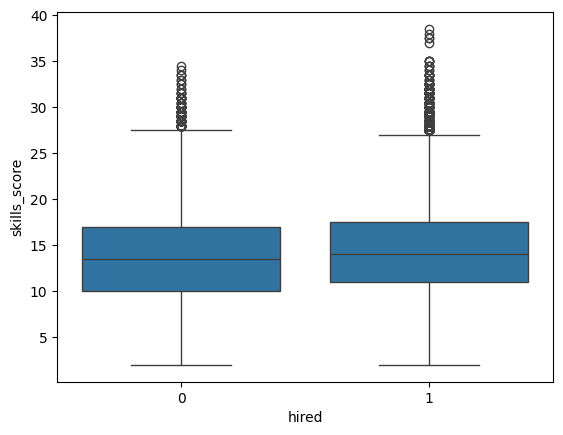

In [158]:
sns.boxplot(x='hired', y='skills_score', data=df)
plt.show()

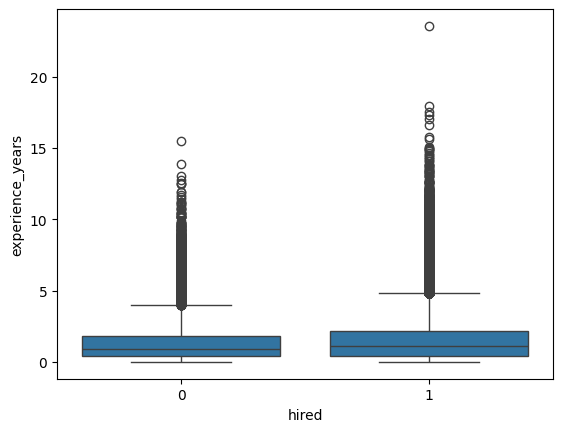

In [159]:
sns.boxplot(x='hired', y='experience_years', data=df)
plt.show()

In [160]:
le = LabelEncoder()
df['education_level'] = le.fit_transform(df['education_level'])

df = pd.get_dummies(df, columns=['university_tier', 'company_type'], drop_first=True)

In [161]:
df.head()

,age,education_level,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,university_tier_Tier 2,university_tier_Tier 3,company_type_Mid-size,company_type_Startup
0,27,0,8.16,2,7,2,2,0.33,0,0,21.0,1,5.62,409,True,False,False,False
1,24,0,6.35,3,2,2,2,4.99,0,0,11.0,1,9.66,237,False,True,False,True
2,33,0,7.78,0,2,4,2,0.93,0,0,15.0,1,8.12,435,False,True,False,True
3,31,1,6.92,2,1,4,1,0.37,0,0,11.5,1,7.19,340,False,True,False,False
4,28,1,8.24,3,0,1,2,0.33,0,0,5.0,0,4.09,371,True,False,True,False


In [162]:
df['cgpa_high'] = (df['cgpa'] >= 8).astype(int)
df['cgpa_low'] = (df['cgpa'] < 6.5).astype(int)

df['exp_high'] = (df['experience_years'] > 2).astype(int)
df['exp_fresher'] = (df['experience_years'] < 1).astype(int)

df['skill_density'] = df['skills_score'] / (df['resume_length_words'] + 1)

df['cgpa_x_skills'] = df['cgpa'] * df['skills_score']
df['exp_x_projects'] = df['experience_years'] * df['projects']
df['exp_x_internships'] = df['experience_years'] * df['internships']
df['skills_x_soft'] = df['skills_score'] * df['soft_skills_score']

In [163]:
X = df.drop(columns=['hired'])
y = df['hired']

In [164]:
X.shape

(199799, 26)

In [165]:
X.head()

,age,education_level,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,...,company_type_Startup,cgpa_high,cgpa_low,exp_high,exp_fresher,skill_density,cgpa_x_skills,exp_x_projects,exp_x_internships,skills_x_soft
0,27,0,8.16,2,7,2,2,0.33,0,0,...,False,1,0,0,1,0.051220,171.36,2.31,0.66,118.020
1,24,0,6.35,3,2,2,2,4.99,0,0,...,True,0,1,1,0,0.046218,69.85,9.98,14.97,106.260
2,33,0,7.78,0,2,4,2,0.93,0,0,...,True,0,0,0,1,0.034404,116.70,1.86,0.00,121.800
3,31,1,6.92,2,1,4,1,0.37,0,0,...,False,0,0,0,1,0.033724,79.58,0.37,0.74,82.685
4,28,1,8.24,3,0,1,2,0.33,0,0,...,False,1,0,0,1,0.013441,41.20,0.00,0.99,20.450


In [166]:
X.dtypes

age                         int64
education_level             int64
cgpa                      float64
internships                 int64
projects                    int64
programming_languages       int64
certifications              int64
experience_years          float64
hackathons                  int64
research_papers             int64
skills_score              float64
soft_skills_score         float64
resume_length_words         int64
university_tier_Tier 2       bool
university_tier_Tier 3       bool
company_type_Mid-size        bool
company_type_Startup         bool
cgpa_high                   int64
cgpa_low                    int64
exp_high                    int64
exp_fresher                 int64
skill_density             float64
cgpa_x_skills             float64
exp_x_projects            float64
exp_x_internships         float64
skills_x_soft             float64
dtype: object

In [167]:
X = X.astype(float)

In [168]:
X.dtypes

age                       float64
education_level           float64
cgpa                      float64
internships               float64
projects                  float64
programming_languages     float64
certifications            float64
experience_years          float64
hackathons                float64
research_papers           float64
skills_score              float64
soft_skills_score         float64
resume_length_words       float64
university_tier_Tier 2    float64
university_tier_Tier 3    float64
company_type_Mid-size     float64
company_type_Startup      float64
cgpa_high                 float64
cgpa_low                  float64
exp_high                  float64
exp_fresher               float64
skill_density             float64
cgpa_x_skills             float64
exp_x_projects            float64
exp_x_internships         float64
skills_x_soft             float64
dtype: object

In [169]:
X.head()

,age,education_level,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,...,company_type_Startup,cgpa_high,cgpa_low,exp_high,exp_fresher,skill_density,cgpa_x_skills,exp_x_projects,exp_x_internships,skills_x_soft
0,27.0,0.0,8.16,2.0,7.0,2.0,2.0,0.33,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.051220,171.36,2.31,0.66,118.020
1,24.0,0.0,6.35,3.0,2.0,2.0,2.0,4.99,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,0.046218,69.85,9.98,14.97,106.260
2,33.0,0.0,7.78,0.0,2.0,4.0,2.0,0.93,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.034404,116.70,1.86,0.00,121.800
3,31.0,1.0,6.92,2.0,1.0,4.0,1.0,0.37,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.033724,79.58,0.37,0.74,82.685
4,28.0,1.0,8.24,3.0,0.0,1.0,2.0,0.33,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.013441,41.20,0.00,0.99,20.450


In [170]:
print(X.shape)
print(y.shape)

(199799, 26)
(199799,)


In [171]:
X = X.drop(columns=[
    'research_papers',
    'hackathons'
])

In [172]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [173]:
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42)
# X_train, y_train = smote.fit_resample(X_train, y_train)

In [174]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [175]:
# neg = len(y_train[y_train == 0])
# pos = len(y_train[y_train == 1])

# scale = neg / pos

In [176]:
# from xgboost import XGBClassifier

# model_xg = XGBClassifier(
#     n_estimators=200,
#     max_depth=6,
#     learning_rate=0.05,
#     scale_pos_weight=scale,
#     random_state=42
# )

In [177]:
# model_xg.fit(X_train,y_train)

In [178]:
# probs_xg = model_xg.predict_proba(X_test)[:, 1]

In [179]:
# print("Min prob:", probs_xg.min())
# print("Max prob:", probs_xg.max())
# print("Mean prob:", probs_xg.mean())

In [180]:
# y_pred_xg = model_xg.predict(X_test)

In [181]:
# import numpy as np
# from sklearn.metrics import f1_score

# probs_xg = model_xg.predict_proba(X_test)[:,1]

# thresholds = [0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

# for t in thresholds:
#     y_pred_xg = (probs_xg > t).astype(int)
#     f1 = f1_score(y_test, y_pred_xg)
#     print(classification_report(y_test, y_pred_xg))
#     print(f"Threshold: {t}, F1 Score: {f1}")

In [182]:
# probs_xg = model_xg.predict_proba(X_test)[:,1]
# y_pred = (probs_xg > 0.45).astype(int)

In [183]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [184]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5211961961961962
              precision    recall  f1-score   support

           0       0.33      0.60      0.42     11746
           1       0.75      0.49      0.59     28214

    accuracy                           0.52     39960
   macro avg       0.54      0.54      0.51     39960
weighted avg       0.62      0.52      0.54     39960



In [185]:
import numpy as np
from sklearn.metrics import f1_score

probs = model.predict_proba(X_test)[:,1]

thresholds = [0.4, 0.45, 0.5, 0.55, 0.6]

for t in thresholds:
    y_pred = (probs > t).astype(int)
    f1 = f1_score(y_test, y_pred)
    print(classification_report(y_test, y_pred))
    print(f"Threshold: {t}, F1 Score: {f1}")


              precision    recall  f1-score   support

           0       0.36      0.01      0.02     11746
           1       0.71      0.99      0.83     28214

    accuracy                           0.70     39960
   macro avg       0.53      0.50      0.42     39960
weighted avg       0.60      0.70      0.59     39960

Threshold: 0.4, F1 Score: 0.8250671230047503
              precision    recall  f1-score   support

           0       0.36      0.21      0.26     11746
           1       0.72      0.84      0.78     28214

    accuracy                           0.66     39960
   macro avg       0.54      0.53      0.52     39960
weighted avg       0.61      0.66      0.63     39960

Threshold: 0.45, F1 Score: 0.776477109690883
              precision    recall  f1-score   support

           0       0.33      0.60      0.42     11746
           1       0.75      0.49      0.59     28214

    accuracy                           0.52     39960
   macro avg       0.54      0.54     

In [186]:
probs = model.predict_proba(X_test)[:,1]
y_pred = (probs > 0.45).astype(int)

In [187]:
print("Min prob:", probs.min())
print("Max prob:", probs.max())
print("Mean prob:", probs.mean())

Min prob: 0.36039083393654453
Max prob: 0.9391340230714645
Mean prob: 0.5024644772089103


In [188]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.36      0.21      0.26     11746
           1       0.72      0.84      0.78     28214

    accuracy                           0.66     39960
   macro avg       0.54      0.53      0.52     39960
weighted avg       0.61      0.66      0.63     39960



In [189]:
import numpy as np
import pandas as pd

importance = np.abs(model.coef_[0])

feat_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(feat_df.head(10))

                  feature  importance
7        experience_years    0.175161
8            skills_score    0.165536
3             internships    0.113236
2                    cgpa    0.047664
20          cgpa_x_skills    0.027488
5   programming_languages    0.026543
4                projects    0.018091
23          skills_x_soft    0.011942
6          certifications    0.011739
14   company_type_Startup    0.009473


In [190]:
print(y_pred[:20])
print(probs[:20])

[0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 1]
[0.41838026 0.59013038 0.52138946 0.48580719 0.46636183 0.56536527
 0.57840177 0.51417575 0.62050903 0.50214013 0.45621067 0.58679023
 0.48886264 0.43630651 0.49309986 0.43036994 0.53639487 0.42273815
 0.48468442 0.4904159 ]


In [191]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6569069069069069


In [192]:
import joblib

joblib.dump(model, '../models/model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

with open('../models/threshold.txt', 'w') as f:
    f.write("0.45")

In [193]:
import json

with open('../models/columns.json', 'w') as f:
    json.dump(list(X.columns), f)